# Бэк тест торговой стратегии с управлением рисками

Стратегия основана на пересечении скользящих средних (SMA 5 и SMA 25)

- Начальный депозит: $100,000
- Риск на сделку: 1% от депозита
- R:R = 3 (тейк-профит в 3 раза больше стоп-лосса)
- Комиссия: 0.1% за сделку
- Проскальзывание: 0.05%

In [51]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

In [52]:
# 1. СКАЧИВАЕМ ДАННЫЕ
# Скачиваем историю цены Биткоина за 5 лет
print("Скачиваем данные...")
data = yf.download("BTC-USD", start="2019-01-01", end="2024-01-01")

/tmp/ipykernel_11118/1014554412.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("BTC-USD", start="2019-01-01", end="2024-01-01")
[*********************100%***********************]  1 of 1 completed

Скачиваем данные...


In [53]:
# 2. СОЗДАЕМ ИНДИКАТОРЫ
# Быстрая скользящая средняя (за 10 дней)
data['SMA_5'] = data['Close'].rolling(window=5).mean()
# Медленная скользящая средняя (за 50 дней)
data['SMA_25'] = data['Close'].rolling(window=25).mean()

In [54]:
# 3. ГЕНЕРИРУЕМ СИГНАЛЫ
# Создаем колонку 'Signal', по умолчанию 0 (ничего не делаем)
data['Signal'] = 0

# Если Быстрая > Медленной -> Ставим 1 (Покупать)
data.loc[data['SMA_5'] > data['SMA_25'], 'Signal'] = 1

In [55]:
# 4. БЭКТЕСТ С УПРАВЛЕНИЕМ РИСКАМИ

# Параметры
INITIAL_CAPITAL = 100000  # Начальный депозит
RISK_PER_TRADE = 0.01     # 1% риска от депозита
RR_RATIO = 3              # R:R = 3
COMMISSION = 0.001        # 0.1% комиссия
SLIPPAGE = 0.0005         # 0.05% проскальзывание

# Инициализация переменных
capital = INITIAL_CAPITAL
position = None  # {'entry_price': x, 'entry_idx': i, 'size': n, 'sl': y, 'tp': z}
trades = []
equity_curve = [INITIAL_CAPITAL]
sl_levels = [np.nan] * len(data)
tp_levels = [np.nan] * len(data)
entry_markers = []
exit_markers = []

# Находим точки входа по пересечению SMA
signal_change = data['Signal'].diff()

for idx in range(1, len(data)):
    row = data.iloc[idx]
    current_price = float(row['Close'])
    
    # Если нет позиции, проверяем вход
    if position is None:
        if signal_change.iloc[idx] == 1:  # Вход в позицию
            entry_price = current_price * (1 + SLIPPAGE)
            
            # Рассчитываем размер позиции исходя из 1% риска
            # Используем ATR для стоп-лосса (2 * ATR)
            atr = float(data['High'].iloc[max(0, idx-14):idx+1].max() - 
                       data['Low'].iloc[max(0, idx-14):idx+1].min()) / 2
            stop_loss = entry_price - (2 * atr) if atr > 0 else entry_price * 0.95
            take_profit = entry_price + (RR_RATIO * (entry_price - stop_loss))
            
            # Риск на сделку в долларах
            risk_amount = capital * RISK_PER_TRADE
            
            # Размер позиции (количество монет)
            risk_per_coin = entry_price - stop_loss
            if risk_per_coin > 0:
                position_size = risk_amount / risk_per_coin
            else:
                position_size = (capital * 0.95) / entry_price  # На 95% депозита
            
            # Комиссия при входе
            commission = position_size * entry_price * COMMISSION
            capital -= commission
            
            position = {
                'entry_price': entry_price,
                'entry_idx': idx,
                'size': position_size,
                'sl': stop_loss,
                'tp': take_profit
            }
            
            sl_levels[idx] = stop_loss
            tp_levels[idx] = take_profit
            entry_markers.append((idx, entry_price, 'entry'))
    
    # Если есть позиция, проверяем выход
    else:
        high_price = float(row['High'])
        low_price = float(row['Low'])
        
        exit_price = None
        exit_type = None
        
        # Проверка стоп-лосса
        if low_price <= position['sl']:
            exit_price = position['sl'] * (1 - SLIPPAGE)
            exit_type = 'SL'
        # Проверка тейк-профита
        elif high_price >= position['tp']:
            exit_price = position['tp'] * (1 + SLIPPAGE)
            exit_type = 'TP'
        # Выход по сигналу (SMA пересеклась вниз)
        elif signal_change.iloc[idx] == -1:
            exit_price = current_price * (1 - SLIPPAGE)
            exit_type = 'SIGNAL'
        
        if exit_price:
            # Комиссия при выходе
            commission = position['size'] * exit_price * COMMISSION
            
            # P&L
            pnl = position['size'] * (exit_price - position['entry_price']) - commission
            capital += pnl
            
            trades.append({
                'entry_idx': position['entry_idx'],
                'exit_idx': idx,
                'entry_price': position['entry_price'],
                'exit_price': exit_price,
                'sl': position['sl'],
                'tp': position['tp'],
                'pnl': pnl,
                'exit_type': exit_type,
                'size': position['size']
            })
            
            exit_markers.append((idx, exit_price, exit_type))
            position = None
    
    # Записываем текущее значение капитала
    if position:
        unrealized_pnl = position['size'] * (current_price - position['entry_price'])
        equity_curve.append(INITIAL_CAPITAL + sum(t['pnl'] for t in trades) + unrealized_pnl)
    else:
        equity_curve.append(INITIAL_CAPITAL + sum(t['pnl'] for t in trades))

# Если позиция осталась открытой
if position:
    exit_price = float(data['Close'].iloc[-1]) * (1 - SLIPPAGE)
    commission = position['size'] * exit_price * COMMISSION
    pnl = position['size'] * (exit_price - position['entry_price']) - commission
    capital += pnl
    trades.append({
        'entry_idx': position['entry_idx'],
        'exit_idx': len(data) - 1,
        'entry_price': position['entry_price'],
        'exit_price': exit_price,
        'sl': position['sl'],
        'tp': position['tp'],
        'pnl': pnl,
        'exit_type': 'CLOSE',
        'size': position['size']
    })
    equity_curve[-1] = capital

trades_df = pd.DataFrame(trades)

/tmp/ipykernel_11118/1650999335.py:25: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(row['Close'])
/tmp/ipykernel_11118/1650999335.py:34: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  atr = float(data['High'].iloc[max(0, idx-14):idx+1].max() -
/tmp/ipykernel_11118/1650999335.py:67: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  high_price = float(row['High'])
/tmp/ipykernel_11118/1650999335.py:68: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  low_price = float(row['Low'])


In [56]:
# 5. РЕЗУЛЬТАТЫ
print(f"Начальный депозит: ${INITIAL_CAPITAL:,.2f}")
print(f"Конечный капитал: ${capital:,.2f}")
print(f"Общая доходность: {((capital / INITIAL_CAPITAL) - 1) * 100:.2f}%")
print(f"\nВсего сделок: {len(trades)}")

if len(trades) > 0:
    winning = [t for t in trades if t['pnl'] > 0]
    losing = [t for t in trades if t['pnl'] < 0]
    
    print(f"Прибыльных: {len(winning)} ({len(winning)/len(trades)*100:.1f}%)")
    print(f"Убыточных: {len(losing)} ({len(losing)/len(trades)*100:.1f}%)")
    
    sl_hits = len([t for t in trades if t['exit_type'] == 'SL'])
    tp_hits = len([t for t in trades if t['exit_type'] == 'TP'])
    signal_exits = len([t for t in trades if t['exit_type'] == 'SIGNAL'])
    
    print(f"\nВыходов по стоп-лоссу: {sl_hits}")
    print(f"Выходов по тейк-профиту: {tp_hits}")
    print(f"Выходов по сигналу: {signal_exits}")

Начальный депозит: $100,000.00
Конечный капитал: $119,908.08
Общая доходность: 19.91%

Всего сделок: 42
Прибыльных: 17 (40.5%)
Убыточных: 25 (59.5%)

Выходов по стоп-лоссу: 1
Выходов по тейк-профиту: 8
Выходов по сигналу: 33


In [57]:
# 5.1 ПОДРОБНАЯ СТАТИСТИКА
from IPython.display import display, Markdown

if len(trades) > 0:
    trades_series = pd.Series([t['pnl'] for t in trades])
    winning_trades = trades_series[trades_series > 0]
    losing_trades = trades_series[trades_series < 0]
    
    total_trades = len(trades)
    win_rate = len(winning_trades) / total_trades * 100
    avg_win = float(winning_trades.mean()) if len(winning_trades) > 0 else 0
    avg_loss = abs(float(losing_trades.mean())) if len(losing_trades) > 0 else 0
    avg_rr = avg_win / avg_loss if avg_loss > 0 else 0
    
    gross_profit = float(winning_trades.sum()) if len(winning_trades) > 0 else 0
    gross_loss = abs(float(losing_trades.sum())) if len(losing_trades) > 0 else 0
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else float('inf')
    
    total_return = float(trades_series.sum())
    
    # Коэффициент Шарпа (на основе ежедневной доходности)
    equity_series = pd.Series(equity_curve)
    daily_returns = equity_series.pct_change().dropna()
    sharpe_ratio = float((daily_returns.mean() / daily_returns.std()) * np.sqrt(252)) if daily_returns.std() > 0 else 0
    
    # Максимальная просадка
    equity_max = equity_series.cummax()
    drawdown = (equity_series - equity_max) / equity_max
    max_drawdown = float(drawdown.min())
    
    # Формируем таблицу
    stats_df = pd.DataFrame({
        'Метрика': [
            'Всего сделок',
            'Win Rate (%)',
            'Средний R:R',
            'Profit Factor',
            'Коэф. Шарпа',
            'Макс. просадка (%)',
            'Общая доходность ($)',
            'Общая доходность (%)',
            'Средний выигрыш ($)',
            'Средний проигрыш ($)'
        ],
        'Значение': [
            f'{total_trades}',
            f'{win_rate:.2f}',
            f'{avg_rr:.2f}',
            f'{profit_factor:.2f}',
            f'{sharpe_ratio:.2f}',
            f'{max_drawdown * 100:.2f}',
            f'${total_return:,.2f}',
            f'{(total_return / INITIAL_CAPITAL) * 100:.2f}%',
            f'${avg_win:,.2f}',
            f'${avg_loss:,.2f}'
        ]
    })
    
    display(Markdown("### 📊 Статистика стратегии"))
    display(stats_df.style.hide(axis="index"))

### 📊 Статистика стратегии

Метрика,Значение
Всего сделок,42
Win Rate (%),40.48
Средний R:R,3.88
Profit Factor,2.64
Коэф. Шарпа,1.05
Макс. просадка (%),-5.55
Общая доходность ($),"$20,338.93"
Общая доходность (%),20.34%
Средний выигрыш ($),"$1,925.67"
Средний проигрыш ($),$495.90


/tmp/ipykernel_11118/1283246475.py:18: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  open_price = float(row['Open'])
/tmp/ipykernel_11118/1283246475.py:19: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  close_price = float(row['Close'])
/tmp/ipykernel_11118/1283246475.py:20: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  high_price = float(row['High'])
/tmp/ipykernel_11118/1283246475.py:21: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  low_price = float(row['Low'])
/tmp/ipykernel_11118/1283246475.py:73: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError 


График сохранён в файл: chart_candles.png


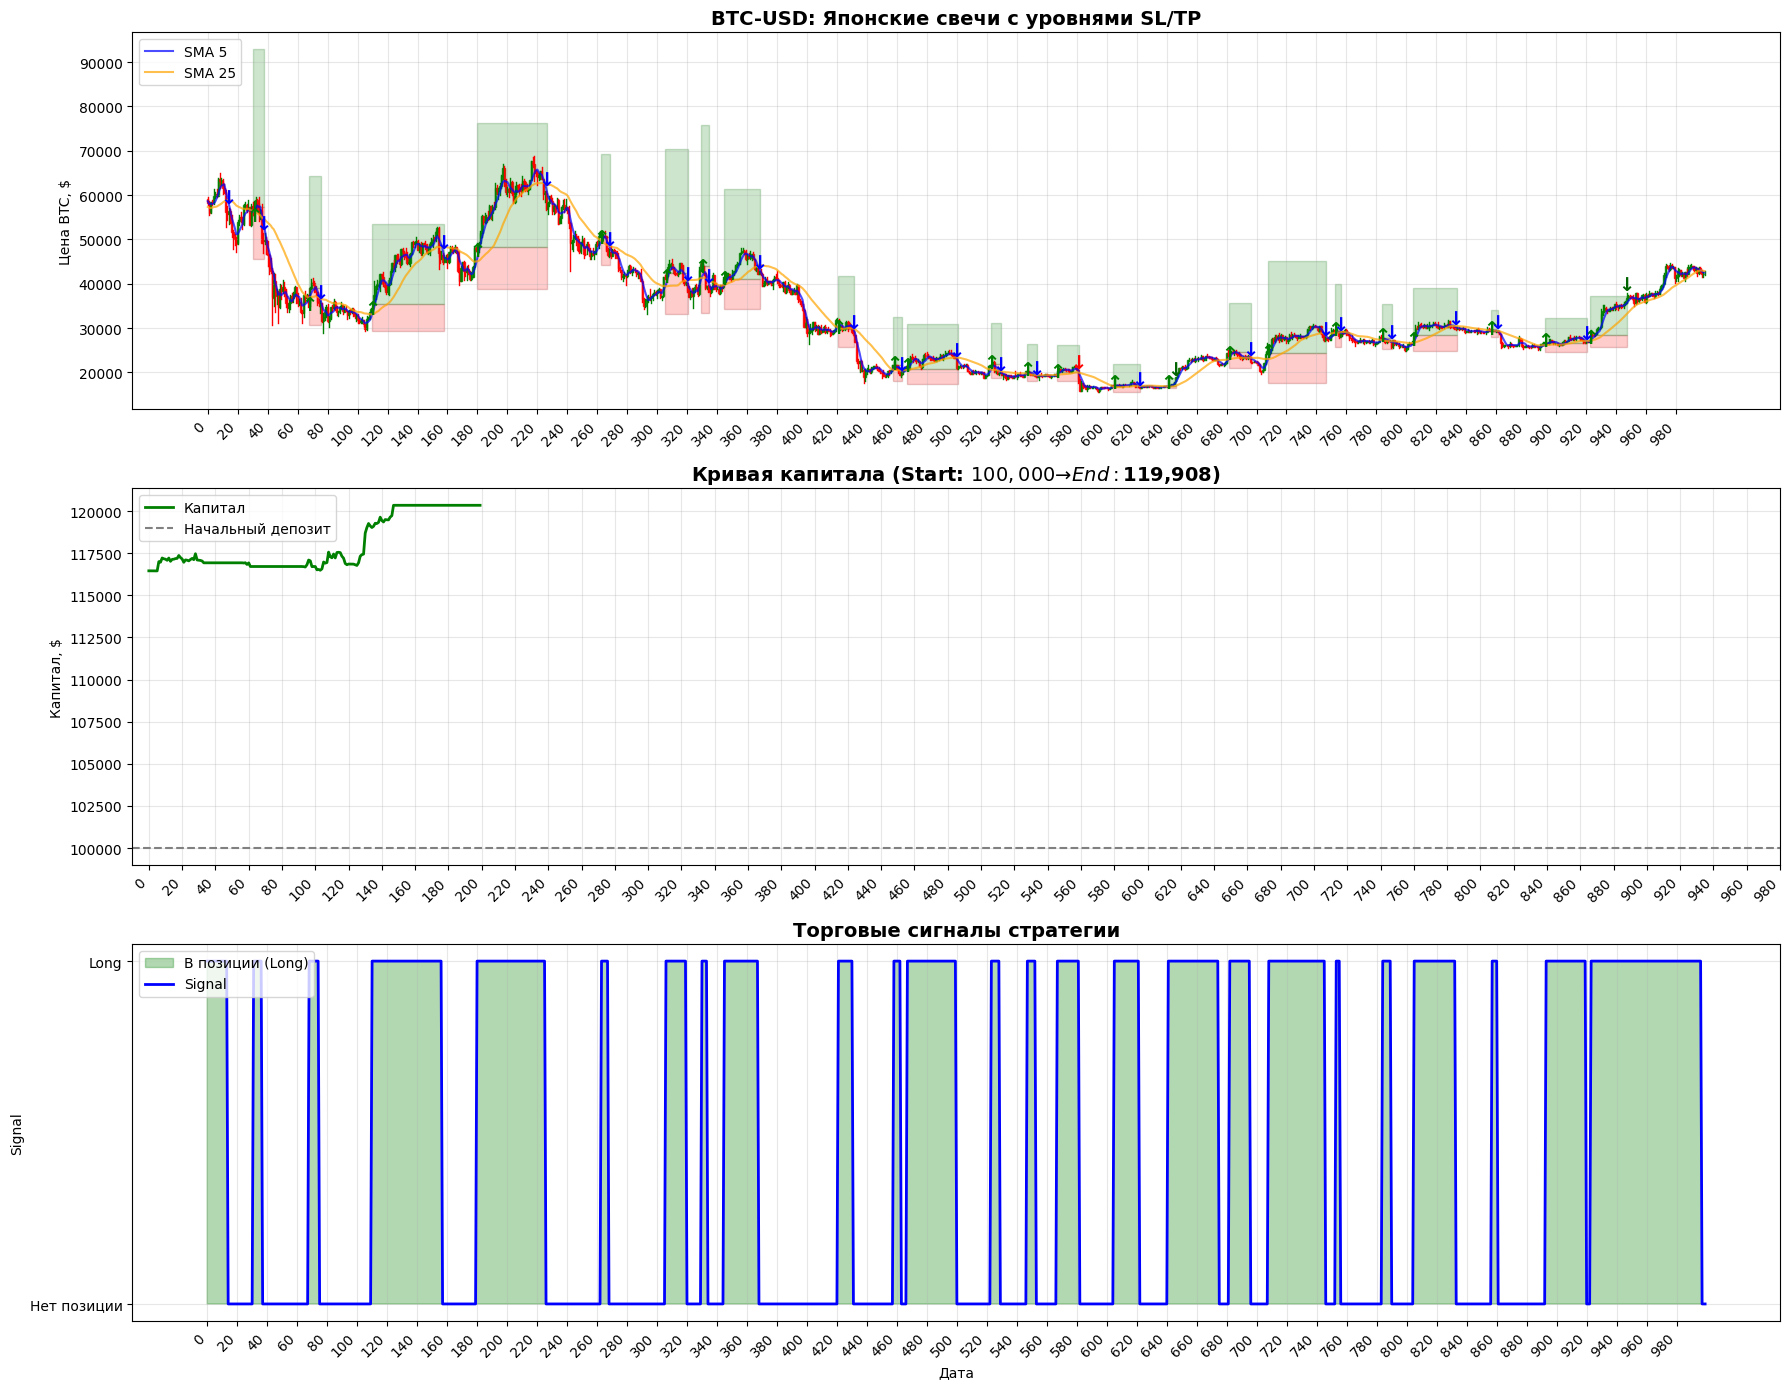

In [58]:
# 6. ВИЗУАЛИЗАЦИЯ

# Берем последние 1000 дней для отображения
df_plot = data.iloc[-1000:].copy()
df_plot = df_plot.reset_index(drop=True)
start_idx = len(data) - 1000

# Создаем фигуру с 3 подграфиками
fig = plt.figure(figsize=(18, 14))

# График 1: Японские свечи с сигналами, SL и TP
ax1 = fig.add_subplot(311)

# Рисуем свечи
for idx in range(len(df_plot)):
    row = df_plot.iloc[idx]
    x = idx
    open_price = float(row['Open'])
    close_price = float(row['Close'])
    high_price = float(row['High'])
    low_price = float(row['Low'])
    
    color = 'green' if close_price >= open_price else 'red'
    ax1.add_patch(plt.Rectangle((x - 0.4, min(open_price, close_price)), 
                                 0.8, abs(close_price - open_price),
                                 facecolor=color, edgecolor=color, alpha=0.8))
    ax1.plot([x, x], [low_price, high_price], color=color, linewidth=1)

# Рисуем скользящие средние
ax1.plot(df_plot.index, df_plot['SMA_5'], 
         label='SMA 5', color='blue', linewidth=1.5, alpha=0.7)
ax1.plot(df_plot.index, df_plot['SMA_25'], 
         label='SMA 25', color='orange', linewidth=1.5, alpha=0.7)

# Рисуем прямоугольники SL и TP для каждой сделки в видимом диапазоне
for trade in trades:
    entry_idx = trade['entry_idx']
    exit_idx = trade['exit_idx']
    
    # Проверяем, попадает ли сделка в видимый диапазон
    if entry_idx >= start_idx and entry_idx < len(data):
        rel_entry_idx = entry_idx - start_idx
        rel_exit_idx = min(exit_idx - start_idx, len(df_plot) - 1)
        
        entry_price = trade['entry_price']
        sl = trade['sl']
        tp = trade['tp']
        
        # Красный прямоугольник для SL (от входа до стопа)
        sl_height = entry_price - sl
        ax1.add_patch(Rectangle(
            (rel_entry_idx - 0.5, sl),
            rel_exit_idx - rel_entry_idx + 1,
            sl_height,
            facecolor='red', edgecolor='darkred', alpha=0.2, linewidth=1,
            label='Stop Loss' if trade == trades[0] else ''
        ))
        
        # Зеленый прямоугольник для TP (от входа до тейка)
        tp_height = tp - entry_price
        ax1.add_patch(Rectangle(
            (rel_entry_idx - 0.5, entry_price),
            rel_exit_idx - rel_entry_idx + 1,
            tp_height,
            facecolor='green', edgecolor='darkgreen', alpha=0.2, linewidth=1,
            label='Take Profit' if trade == trades[0] else ''
        ))

# Добавляем маркеры входов и выходов
for idx, price, marker_type in entry_markers:
    if idx >= start_idx and idx < len(data):
        x = idx - start_idx
        ax1.annotate('↑', xy=(x, float(data['Low'].iloc[idx]) * 0.98), 
                     color='green', fontsize=14, fontweight='bold', ha='center')

for idx, price, exit_type in exit_markers:
    if idx >= start_idx and idx < len(data):
        x = idx - start_idx
        color = 'red' if exit_type == 'SL' else ('darkgreen' if exit_type == 'TP' else 'blue')
        ax1.annotate('↓', xy=(x, float(data['High'].iloc[idx]) * 1.02), 
                     color=color, fontsize=14, fontweight='bold', ha='center')

ax1.legend(loc='upper left')
ax1.set_ylabel('Цена BTC, $')
ax1.set_title('BTC-USD: Японские свечи с уровнями SL/TP', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Устанавливаем дату на нижнюю ось
tick_indices = range(0, len(df_plot), 20)
ax1.set_xticks(list(tick_indices))
ax1.set_xticklabels([df_plot.index[i].strftime('%Y-%m-%d') if hasattr(df_plot.index[i], 'strftime') else str(i) 
                     for i in tick_indices], rotation=45, ha='right')

# График 2: Кривая капитала
ax2 = fig.add_subplot(312)
equity_df = pd.DataFrame({'Equity': equity_curve}, index=data.index)
ax2.plot(equity_df['Equity'].iloc[-200:].reset_index(drop=True), label='Капитал', color='green', linewidth=2)
ax2.axhline(y=INITIAL_CAPITAL, color='gray', linestyle='--', linewidth=1.5, label='Начальный депозит')
ax2.set_title(f'Кривая капитала (Start: ${INITIAL_CAPITAL:,.0f} → End: ${capital:,.0f})', fontsize=14, fontweight='bold')
ax2.set_ylabel('Капитал, $')
ax2.legend(loc='upper left')
ax2.grid(True, alpha=0.3)

# График 3: Сигналы (Signal)
ax3 = fig.add_subplot(313)
ax3.fill_between(df_plot.index, 0, df_plot['Signal'], 
                 where=(df_plot['Signal'] == 1), 
                 interpolate=True, color='green', alpha=0.3, label='В позиции (Long)')
ax3.plot(df_plot['Signal'], label='Signal', color='blue', linewidth=2)
ax3.set_title('Торговые сигналы стратегии', fontsize=14, fontweight='bold')
ax3.set_xlabel('Дата')
ax3.set_ylabel('Signal')
ax3.set_yticks([0, 1])
ax3.set_yticklabels(['Нет позиции', 'Long'])
ax3.legend(loc='upper left')
ax3.grid(True, alpha=0.3)

# Устанавливаем дату на ось для нижних графиков
for ax in [ax2, ax3]:
    ax.set_xticks(list(tick_indices))
    ax.set_xticklabels([df_plot.index[i].strftime('%Y-%m-%d') if hasattr(df_plot.index[i], 'strftime') else str(i) 
                        for i in tick_indices], rotation=45, ha='right')

plt.tight_layout()
plt.savefig('chart_candles.png', dpi=150, bbox_inches='tight')
print("\nГрафик сохранён в файл: chart_candles.png")
plt.show()